# Stock Price Prediction -- Feature Assembly & Modeling

This notebook:

1. **Merges** price-based features (`features_price.csv`) with NLP features (`features_nlp.csv`)
2. **Scales** features using dual MinMaxScalers (separate for features vs target, from SOTA)
3. **Evaluates baselines**: naive forecast, moving average forecast
4. **Trains XGBoost** with walk-forward (expanding window) validation
5. **Ablation study**: price-only vs price+NLP features
6. **Final evaluation**: RMSE, MAE, MAPE, Directional Accuracy

**Input:** `features_price.csv`, `features_nlp.csv`

**Output:** Model predictions, evaluation metrics, feature importance plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '..'
RANDOM_STATE = 42
TRAIN_PCT = 0.7
np.random.seed(RANDOM_STATE)

## 1. Load and Merge Features

In [2]:
price_features = pd.read_csv(f'{DATA_DIR}/features_price.csv', parse_dates=['date'])
nlp_features = pd.read_csv(f'{DATA_DIR}/features_nlp.csv', parse_dates=['date'])

print(f'Price features: {price_features.shape}')
print(f'NLP features:   {nlp_features.shape}')

df = price_features.merge(nlp_features, on=['date', 'ticker'], how='left')

df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Fill any remaining NaN in NLP columns for days without news match
nlp_cols = [c for c in nlp_features.columns if c not in ['date', 'ticker']]
for col in nlp_cols:
    if col == 'has_news':
        df[col] = df[col].fillna(0).astype(int)
    else:
        df[col] = df[col].fillna(0.0)

# Drop rows where target is NaN (last row per ticker)
df = df.dropna(subset=['target_next_close']).reset_index(drop=True)

tickers = sorted(df['ticker'].unique())
print(f'\nMerged shape: {df.shape}')
print(f'Tickers: {tickers}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Rows per ticker:')
display(df.groupby('ticker').size())

Price features: (1449, 49)
NLP features:   (1687, 35)

Merged shape: (1449, 82)
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Date range: 2024-01-02 00:00:00 to 2024-10-25 00:00:00
Rows per ticker:


ticker
AAPL     207
AMZN     207
GOOGL    207
META     207
MSFT     207
NVDA     207
TSLA     207
dtype: int64

## 2. Define Feature Groups

In [3]:
META_COLS = ['date', 'ticker']
TARGET_COLS = ['target_next_close', 'target_next_return', 'target_direction']
OHLCV_COLS = ['open', 'high', 'low', 'close', 'volume']
EXCLUDE_COLS = META_COLS + TARGET_COLS + ['is_outlier']

# Price-based feature columns (from features_price.csv, excluding OHLCV and meta/target)
price_feature_cols = [
    c for c in price_features.columns
    if c not in EXCLUDE_COLS + OHLCV_COLS
]

# NLP feature columns
nlp_feature_cols = [c for c in nlp_cols]

# All feature columns (price + NLP, excluding raw OHLCV)
all_feature_cols = price_feature_cols + nlp_feature_cols

print(f'Price features:  {len(price_feature_cols)}')
print(f'NLP features:    {len(nlp_feature_cols)}')
print(f'Total features:  {len(all_feature_cols)}')
print(f'\nNLP feature names:')
for c in nlp_feature_cols:
    print(f'  {c}')

Price features:  38
NLP features:    33
Total features:  71

NLP feature names:
  has_news
  news_count
  sent_compound
  sent_compound_std
  sent_compound_min
  sent_compound_max
  sent_positive
  sent_negative
  positive_ratio
  negative_ratio
  sent_compound_roll5
  sent_compound_std_roll5
  sent_compound_min_roll5
  sent_compound_max_roll5
  sent_positive_roll5
  sent_negative_roll5
  positive_ratio_roll5
  negative_ratio_roll5
  emb_pca_0
  emb_pca_1
  emb_pca_2
  emb_pca_3
  emb_pca_4
  emb_pca_5
  emb_pca_6
  emb_pca_7
  emb_pca_8
  emb_pca_9
  emb_pca_10
  emb_pca_11
  emb_pca_12
  emb_pca_13
  emb_pca_14


## 3. Joint Feature Importance (Price + NLP)

Quick XGBoost importance check to see which NLP features contribute alongside price features.

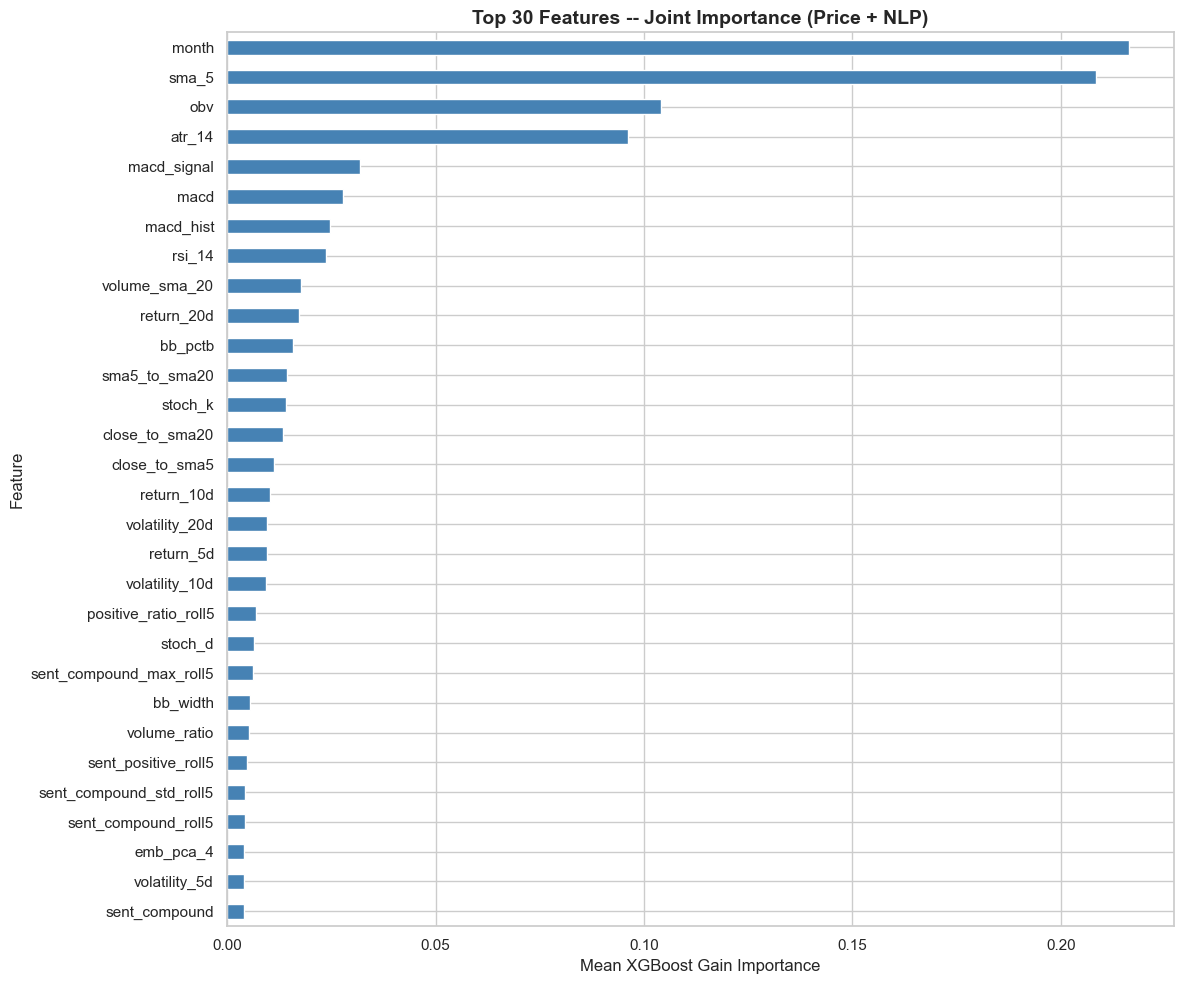


NLP features in top 30: 7 / 33
  positive_ratio_roll5: 0.0069
  sent_compound_max_roll5: 0.0061
  sent_positive_roll5: 0.0047
  sent_compound_std_roll5: 0.0044
  sent_compound_roll5: 0.0042
  emb_pca_4: 0.0040
  sent_compound: 0.0039


In [4]:
joint_importance = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy()
    X = sub[all_feature_cols].values
    y = sub['target_next_close'].values

    split_idx = int(len(X) * 0.8)
    X_train, y_train = X[:split_idx], y[:split_idx]

    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        verbosity=0
    )
    model.fit(X_train, y_train)

    imp = model.feature_importances_
    joint_importance[ticker] = pd.Series(imp, index=all_feature_cols)

importance_df = pd.DataFrame(joint_importance)
importance_df['mean_importance'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean_importance', ascending=False)

# Top 30 features
top30 = importance_df.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
top30['mean_importance'].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 30 Features -- Joint Importance (Price + NLP)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean XGBoost Gain Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# How many NLP features in top 30?
nlp_in_top30 = [c for c in top30.index if c in nlp_feature_cols]
print(f'\nNLP features in top 30: {len(nlp_in_top30)} / {len(nlp_feature_cols)}')
for c in nlp_in_top30:
    print(f'  {c}: {importance_df.loc[c, "mean_importance"]:.4f}')

## 4. Walk-Forward Validation Framework

Expanding window approach:
- Initial training: first 60% of data (~145 days)
- Step forward 5 days at a time
- Retrain at each step
- Predict next day at each point

In [5]:
def walk_forward_evaluate(ticker_df, feature_cols, target_col,
                          model_fn, initial_train_pct=TRAIN_PCT, step_size=5,
                          verbose=True, ticker_name=''):
    """Walk-forward validation with expanding window.

    Returns a DataFrame with columns: date, actual, predicted.
    """
    n = len(ticker_df)
    initial_train_size = int(n * initial_train_pct)
    total_steps = (n - initial_train_size + step_size - 1) // step_size

    dates = ticker_df['date'].values
    X = ticker_df[feature_cols].values
    y = ticker_df[target_col].values

    results = []

    train_end = initial_train_size
    step_num = 0
    while train_end < n:
        step_num += 1
        X_train, y_train = X[:train_end], y[:train_end]

        predict_end = min(train_end + step_size, n)
        X_test = X[train_end:predict_end]
        y_test = y[train_end:predict_end]
        test_dates = dates[train_end:predict_end]

        model = model_fn()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        for d, actual, pred in zip(test_dates, y_test, preds):
            results.append({'date': d, 'actual': actual, 'predicted': pred})

        if verbose and (step_num % 4 == 0 or step_num == 1 or train_end + step_size >= n):
            print(f'  {ticker_name} step {step_num}/{total_steps}  '
                  f'train={train_end}  test={predict_end - train_end} days')

        train_end = predict_end

    return pd.DataFrame(results)


def compute_metrics(results_df):
    """Compute RMSE, MAE, MAPE, Directional Accuracy."""
    actual = results_df['actual'].values
    predicted = results_df['predicted'].values

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Directional accuracy: did we predict the direction of change correctly?
    actual_dir = np.diff(actual) > 0
    pred_dir = np.diff(predicted) > 0
    dir_acc = np.mean(actual_dir == pred_dir) * 100 if len(actual_dir) > 0 else 0.0

    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Dir_Acc': dir_acc}


print('Walk-forward framework ready.')

Walk-forward framework ready.


## 5. Baseline Models

Two baselines to set the performance floor:
1. **Naive**: predict next close = today's close
2. **SMA-5**: predict next close = 5-day simple moving average of close

In [6]:
baseline_results = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    n = len(sub)
    initial_train_size = int(n * TRAIN_PCT)

    test_data = sub.iloc[initial_train_size:].copy()

    # Naive: predict close_{t+1} = close_t
    naive_preds = test_data['close'].values
    naive_actual = test_data['target_next_close'].values

    naive_df = pd.DataFrame({
        'date': test_data['date'].values,
        'actual': naive_actual,
        'predicted': naive_preds
    })

    # SMA-5: predict close_{t+1} = SMA_5(close)
    sma5_preds = test_data['sma_5'].values
    sma5_df = pd.DataFrame({
        'date': test_data['date'].values,
        'actual': naive_actual,
        'predicted': sma5_preds
    })

    baseline_results[ticker] = {
        'naive': compute_metrics(naive_df),
        'sma5': compute_metrics(sma5_df),
    }

# Display baseline results
print('=== Baseline Results ===')
print(f'{"Ticker":<8} {"Model":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 58)
for ticker in tickers:
    for model_name in ['naive', 'sma5']:
        m = baseline_results[ticker][model_name]
        print(f'{ticker:<8} {model_name:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

=== Baseline Results ===
Ticker   Model          RMSE        MAE      MAPE%   Dir_Acc%
----------------------------------------------------------
AAPL     naive          3.10       2.27       1.02       45.2
AAPL     sma5           4.17       3.30       1.48       37.1
AMZN     naive          3.56       2.52       1.41       51.6
AMZN     sma5           5.51       4.11       2.32       48.4
GOOGL    naive          2.28       1.75       1.09       54.8
GOOGL    sma5           3.68       2.84       1.78       56.5
META     naive          8.64       6.54       1.22       38.7
META     sma5          12.45       9.86       1.84       46.8
MSFT     naive          4.55       3.57       0.86       54.8
MSFT     sma5           7.77       6.17       1.48       50.0
NVDA     naive          4.32       3.36       2.84       43.5
NVDA     sma5           6.44       5.11       4.30       46.8
TSLA     naive          9.58       6.56       2.88       43.5
TSLA     sma5          13.07       9.73       4.

## 6. XGBoost Walk-Forward (Price Features Only)

First run with price features only to establish the ML baseline.

In [7]:
def make_xgb_model():
    return xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=5,
        random_state=RANDOM_STATE, verbosity=0
    )


xgb_price_results = {}
xgb_price_predictions = {}

print('=== XGBoost Default (Price Features Only) -- Walk-Forward ===')
for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    preds_df = walk_forward_evaluate(
        sub, price_feature_cols, 'target_next_close',
        make_xgb_model, initial_train_pct=TRAIN_PCT, step_size=5,
        ticker_name=ticker
    )
    xgb_price_results[ticker] = compute_metrics(preds_df)
    xgb_price_predictions[ticker] = preds_df

print('\n=== XGBoost (Price Features Only) -- Results ===')
print(f'{"Ticker":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 50)
for ticker in tickers:
    m = xgb_price_results[ticker]
    print(f'{ticker:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

=== XGBoost Default (Price Features Only) -- Walk-Forward ===
  AAPL step 1/13  train=144  test=5 days
  AAPL step 4/13  train=159  test=5 days
  AAPL step 8/13  train=179  test=5 days
  AAPL step 12/13  train=199  test=5 days
  AAPL step 13/13  train=204  test=3 days
  AMZN step 1/13  train=144  test=5 days
  AMZN step 4/13  train=159  test=5 days
  AMZN step 8/13  train=179  test=5 days
  AMZN step 12/13  train=199  test=5 days
  AMZN step 13/13  train=204  test=3 days
  GOOGL step 1/13  train=144  test=5 days
  GOOGL step 4/13  train=159  test=5 days
  GOOGL step 8/13  train=179  test=5 days
  GOOGL step 12/13  train=199  test=5 days
  GOOGL step 13/13  train=204  test=3 days
  META step 1/13  train=144  test=5 days
  META step 4/13  train=159  test=5 days
  META step 8/13  train=179  test=5 days
  META step 12/13  train=199  test=5 days
  META step 13/13  train=204  test=3 days
  MSFT step 1/13  train=144  test=5 days
  MSFT step 4/13  train=159  test=5 days
  MSFT step 8/13  train

## 7. XGBoost Walk-Forward (Price + NLP Features)

Now add NLP features to see if sentiment improves predictions.

In [8]:
xgb_all_results = {}
xgb_all_predictions = {}

print('=== XGBoost Default (Price + NLP) -- Walk-Forward ===')
for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    preds_df = walk_forward_evaluate(
        sub, all_feature_cols, 'target_next_close',
        make_xgb_model, initial_train_pct=TRAIN_PCT, step_size=5,
        ticker_name=ticker
    )
    xgb_all_results[ticker] = compute_metrics(preds_df)
    xgb_all_predictions[ticker] = preds_df

print('\n=== XGBoost (Price + NLP Features) -- Results ===')
print(f'{"Ticker":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 50)
for ticker in tickers:
    m = xgb_all_results[ticker]
    print(f'{ticker:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

=== XGBoost Default (Price + NLP) -- Walk-Forward ===
  AAPL step 1/13  train=144  test=5 days
  AAPL step 4/13  train=159  test=5 days
  AAPL step 8/13  train=179  test=5 days
  AAPL step 12/13  train=199  test=5 days
  AAPL step 13/13  train=204  test=3 days
  AMZN step 1/13  train=144  test=5 days
  AMZN step 4/13  train=159  test=5 days
  AMZN step 8/13  train=179  test=5 days
  AMZN step 12/13  train=199  test=5 days
  AMZN step 13/13  train=204  test=3 days
  GOOGL step 1/13  train=144  test=5 days
  GOOGL step 4/13  train=159  test=5 days
  GOOGL step 8/13  train=179  test=5 days
  GOOGL step 12/13  train=199  test=5 days
  GOOGL step 13/13  train=204  test=3 days
  META step 1/13  train=144  test=5 days
  META step 4/13  train=159  test=5 days
  META step 8/13  train=179  test=5 days
  META step 12/13  train=199  test=5 days
  META step 13/13  train=204  test=3 days
  MSFT step 1/13  train=144  test=5 days
  MSFT step 4/13  train=159  test=5 days
  MSFT step 8/13  train=179  te

## 8. Hyperparameter Optimization (GridSearchCV)

Use `GridSearchCV` with `TimeSeriesSplit` to find the best XGBoost hyperparameters. We pool all tickers chronologically and search over key regularization and tree parameters.

In [9]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

grid_data = []
for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    n = len(sub)
    train_size = int(n * TRAIN_PCT)
    grid_data.append(sub.iloc[:train_size])

grid_df = pd.concat(grid_data, ignore_index=True)
X_grid = grid_df[all_feature_cols].values
y_grid = grid_df['target_next_close'].values

param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [3, 5, 10],
}

tscv = TimeSeriesSplit(n_splits=3)

base_model = xgb.XGBRegressor(
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    refit=True
)

print(f'Grid search: {len(param_grid["max_depth"]) * len(param_grid["learning_rate"]) * len(param_grid["n_estimators"]) * len(param_grid["subsample"]) * len(param_grid["colsample_bytree"]) * len(param_grid["min_child_weight"])} combinations x {tscv.n_splits} folds')
print(f'Training data: {X_grid.shape}')

grid_search.fit(X_grid, y_grid)

print(f'\nBest score (neg MSE): {grid_search.best_score_:.4f}')
print(f'Best RMSE: {np.sqrt(-grid_search.best_score_):.4f}')
print(f'\nBest parameters:')
for param, value in grid_search.best_params_.items():
    print(f'  {param}: {value}')

best_params = grid_search.best_params_

Grid search: 729 combinations x 3 folds
Training data: (1008, 71)
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max

## 9. Walk-Forward with Tuned Hyperparameters

Re-run the walk-forward evaluation using the GridSearch best parameters, for both price-only and price+NLP feature sets.

In [10]:
def make_tuned_xgb_model():
    return xgb.XGBRegressor(
        **best_params,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, verbosity=0
    )


# --- Tuned: Price features only ---
tuned_price_results = {}
tuned_price_predictions = {}

print('=== Tuned XGBoost (Price Features Only) -- Walk-Forward ===')
for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    preds_df = walk_forward_evaluate(
        sub, price_feature_cols, 'target_next_close',
        make_tuned_xgb_model, initial_train_pct=TRAIN_PCT, step_size=5,
        ticker_name=ticker
    )
    tuned_price_results[ticker] = compute_metrics(preds_df)
    tuned_price_predictions[ticker] = preds_df

print('\n=== Tuned XGBoost (Price Features Only) -- Results ===')
print(f'{"Ticker":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 50)
for ticker in tickers:
    m = tuned_price_results[ticker]
    print(f'{ticker:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

# --- Tuned: All features (Price + NLP) ---
tuned_all_results = {}
tuned_all_predictions = {}

print('\n=== Tuned XGBoost (Price + NLP) -- Walk-Forward ===')
for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    preds_df = walk_forward_evaluate(
        sub, all_feature_cols, 'target_next_close',
        make_tuned_xgb_model, initial_train_pct=TRAIN_PCT, step_size=5,
        ticker_name=ticker
    )
    tuned_all_results[ticker] = compute_metrics(preds_df)
    tuned_all_predictions[ticker] = preds_df

print('\n=== Tuned XGBoost (Price + NLP Features) -- Results ===')
print(f'{"Ticker":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 50)
for ticker in tickers:
    m = tuned_all_results[ticker]
    print(f'{ticker:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

# --- Default vs Tuned comparison ---
print('\n=== Default vs Tuned (Mean Across Tickers) ===')
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"MAPE%":>8} {"Dir%":>8}')
print('-' * 58)

for label, results in [('XGB Default (Price)', xgb_price_results),
                        ('XGB Tuned (Price)', tuned_price_results),
                        ('XGB Default (All)', xgb_all_results),
                        ('XGB Tuned (All)', tuned_all_results)]:
    means = {k: np.mean([r[k] for r in results.values()]) for k in ['RMSE', 'MAE', 'MAPE', 'Dir_Acc']}
    print(f'{label:<25} {means["RMSE"]:>8.2f} {means["MAE"]:>8.2f} {means["MAPE"]:>8.2f} {means["Dir_Acc"]:>8.1f}')

=== Tuned XGBoost (Price Features Only) -- Walk-Forward ===
  AAPL step 1/13  train=144  test=5 days
  AAPL step 4/13  train=159  test=5 days
  AAPL step 8/13  train=179  test=5 days
  AAPL step 12/13  train=199  test=5 days
  AAPL step 13/13  train=204  test=3 days
  AMZN step 1/13  train=144  test=5 days
  AMZN step 4/13  train=159  test=5 days
  AMZN step 8/13  train=179  test=5 days
  AMZN step 12/13  train=199  test=5 days
  AMZN step 13/13  train=204  test=3 days
  GOOGL step 1/13  train=144  test=5 days
  GOOGL step 4/13  train=159  test=5 days
  GOOGL step 8/13  train=179  test=5 days
  GOOGL step 12/13  train=199  test=5 days
  GOOGL step 13/13  train=204  test=3 days
  META step 1/13  train=144  test=5 days
  META step 4/13  train=159  test=5 days
  META step 8/13  train=179  test=5 days
  META step 12/13  train=199  test=5 days
  META step 13/13  train=204  test=3 days
  MSFT step 1/13  train=144  test=5 days
  MSFT step 4/13  train=159  test=5 days
  MSFT step 8/13  train=1

## 10. Ablation Study: Baselines vs Default vs Tuned XGBoost

In [11]:
ablation_rows = []

MODEL_ORDER = ['Naive', 'SMA-5', 'XGB_Price', 'XGB_All', 'XGB_Tuned_Price', 'XGB_Tuned_All']

for ticker in tickers:
    for model_name, results_dict in [
        ('Naive', baseline_results[ticker]['naive']),
        ('SMA-5', baseline_results[ticker]['sma5']),
        ('XGB_Price', xgb_price_results[ticker]),
        ('XGB_All', xgb_all_results[ticker]),
        ('XGB_Tuned_Price', tuned_price_results[ticker]),
        ('XGB_Tuned_All', tuned_all_results[ticker]),
    ]:
        ablation_rows.append({
            'Ticker': ticker,
            'Model': model_name,
            **results_dict
        })

ablation_df = pd.DataFrame(ablation_rows)

print('=== Full Ablation Comparison ===')
display(ablation_df.pivot_table(
    index='Ticker', columns='Model',
    values=['RMSE', 'MAE', 'MAPE', 'Dir_Acc'],
    aggfunc='first'
).round(2))

print('\n=== Average Across All Tickers ===')
summary = ablation_df.groupby('Model')[['RMSE', 'MAE', 'MAPE', 'Dir_Acc']].mean().round(2)
summary = summary.reindex(MODEL_ORDER)
display(summary)

=== Full Ablation Comparison ===


Dir_Acc                                                          MAE  \
Model    Naive  SMA-5 XGB_All XGB_Price XGB_Tuned_All XGB_Tuned_Price Naive   
Ticker                                                                        
AAPL     45.16  37.10   50.00     50.00         56.45           54.84  2.27   
AMZN     51.61  48.39   51.61     53.23         51.61           48.39  2.52   
GOOGL    54.84  56.45   50.00     58.06         50.00           58.06  1.75   
META     38.71  46.77   43.55     41.94         37.10           46.77  6.54   
MSFT     54.84  50.00   54.84     50.00         46.77           46.77  3.57   
NVDA     43.55  46.77   51.61     53.23         48.39           54.84  3.36   
TSLA     43.55  51.61   51.61     43.55         43.55           38.71  6.56   

                                ...    MAPE                          \
Model  SMA-5 XGB_All XGB_Price  ... XGB_All XGB_Price XGB_Tuned_All   
Ticker                          ...                                   
AAPL    3.30    3.85      3.74  ...    1.71      1.66          1.66   
AMZN    4.11    3.49      3.72  ...    1.97      2.10          1.98   
GOOGL   2.84    3.68      3.89  ...    2.30      2.44          2.64   
META    9.86   17.20     15.96  ...    3.16      2.93          3.13   
MSFT    6.17    4.71      4.25  ...    1.13      1.02          1.21   
NVDA    5.11    5.16      4.73  ...    4.19      3.84          4.47   
TSLA    9.73   11.35     10.76  ...    5.01      4.74          5.12   

                        RMSE                                         \
Model  XGB_Tuned_Price Naive  SMA-5 XGB_All XGB_Price XGB_Tuned_All   
Ticker                                                                
AAPL              1.62  3.10   4.17    4.68      4.60          4.55   
AMZN              2.35  3.56   5.51    4.97      5.27          4.79   
GOOGL             2.39  2.28   3.68    4.78      4.97          5.12   
META              3.06  8.64  12.45   20.34     19.19         20.32   
MSFT              1.10  4.55   7.77    6.13      5.58          6.50   
NVDA              4.05  4.32   6.44    6.39      5.95          6.61   
TSLA              5.00  9.58  13.07   15.13     14.98         15.12   

                        
Model  XGB_Tuned_Price  
Ticker                  
AAPL              4.53  
AMZN              5.53  
GOOGL             4.79  
META             20.36  
MSFT              5.81  
NVDA              6.05  
TSLA             15.36  

[7 rows x 24 columns]


=== Average Across All Tickers ===


,RMSE,MAE,MAPE,Dir_Acc
Model,,,,
Naive,5.15,3.79,1.62,47.47
SMA-5,7.58,5.88,2.49,48.16
XGB_Price,8.65,6.72,2.68,50.00
XGB_All,8.92,7.06,2.78,50.46
XGB_Tuned_Price,8.92,7.05,2.80,49.77
XGB_Tuned_All,9.00,7.26,2.89,47.70


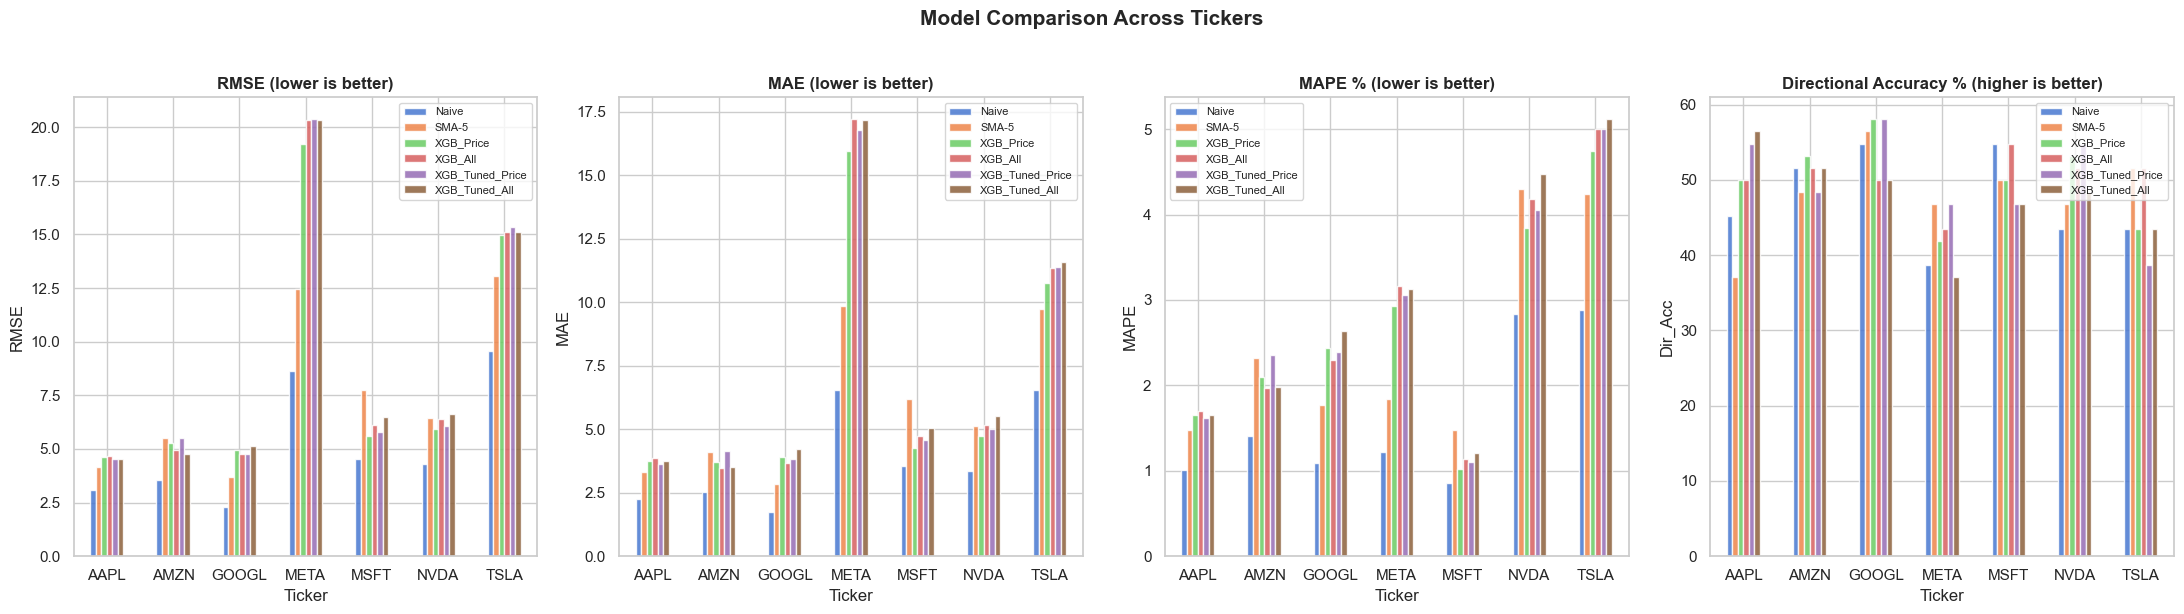

In [12]:
# Ablation bar charts
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics = ['RMSE', 'MAE', 'MAPE', 'Dir_Acc']
titles = ['RMSE (lower is better)', 'MAE (lower is better)',
          'MAPE % (lower is better)', 'Directional Accuracy % (higher is better)']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = ablation_df.pivot(index='Ticker', columns='Model', values=metric)
    pivot = pivot[MODEL_ORDER]
    pivot.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Ticker')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison Across Tickers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Predicted vs Actual Overlay (Default vs Tuned)

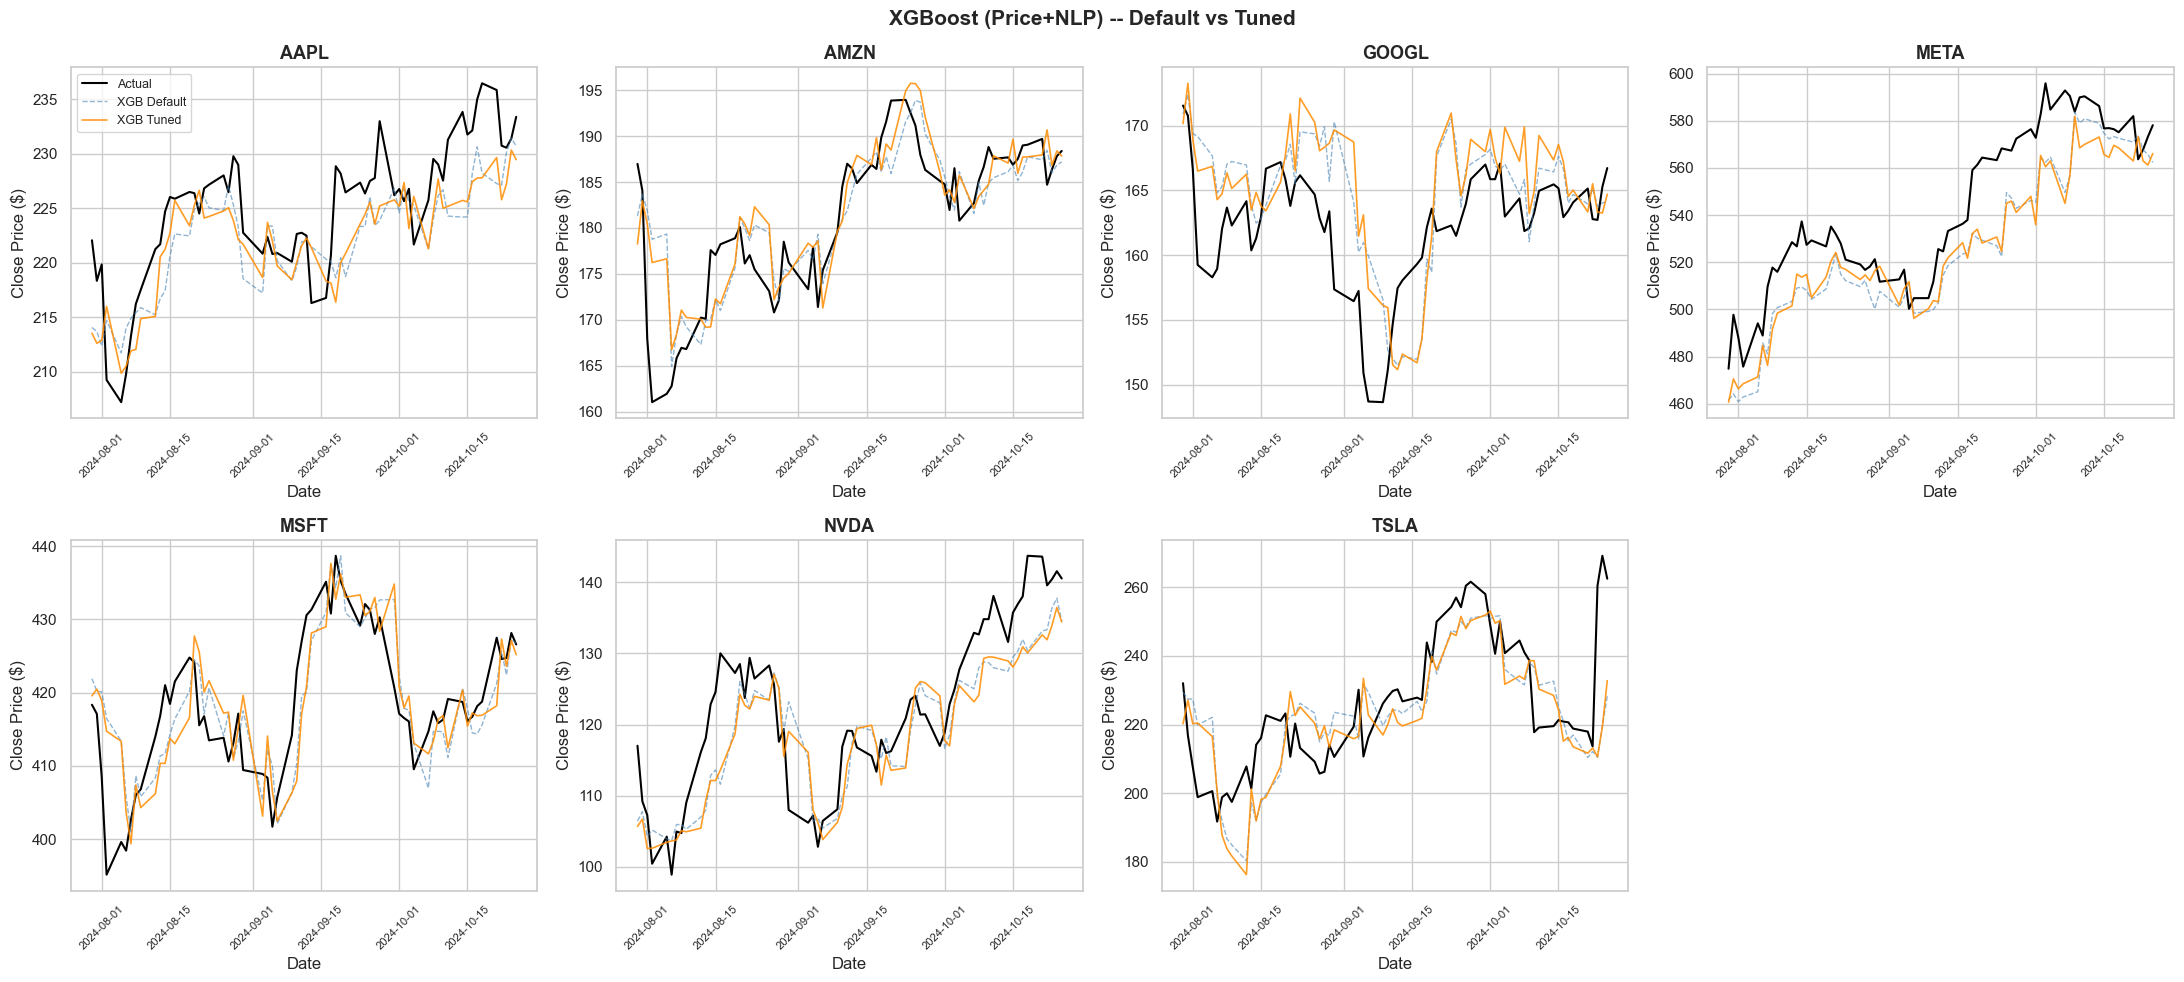

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    preds = xgb_all_predictions[ticker]

    preds_tuned = tuned_all_predictions[ticker]

    axes[i].plot(preds['date'], preds['actual'], label='Actual', linewidth=1.5, color='black')
    axes[i].plot(preds['date'], preds['predicted'], label='XGB Default',
                 linewidth=1.0, color='steelblue', alpha=0.6, linestyle='--')
    axes[i].plot(preds_tuned['date'], preds_tuned['predicted'], label='XGB Tuned',
                 linewidth=1.2, color='darkorange', alpha=0.85)

    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Close Price ($)')
    if i == 0:
        axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('XGBoost (Price+NLP) -- Default vs Tuned', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Residual Analysis (Tuned Model)

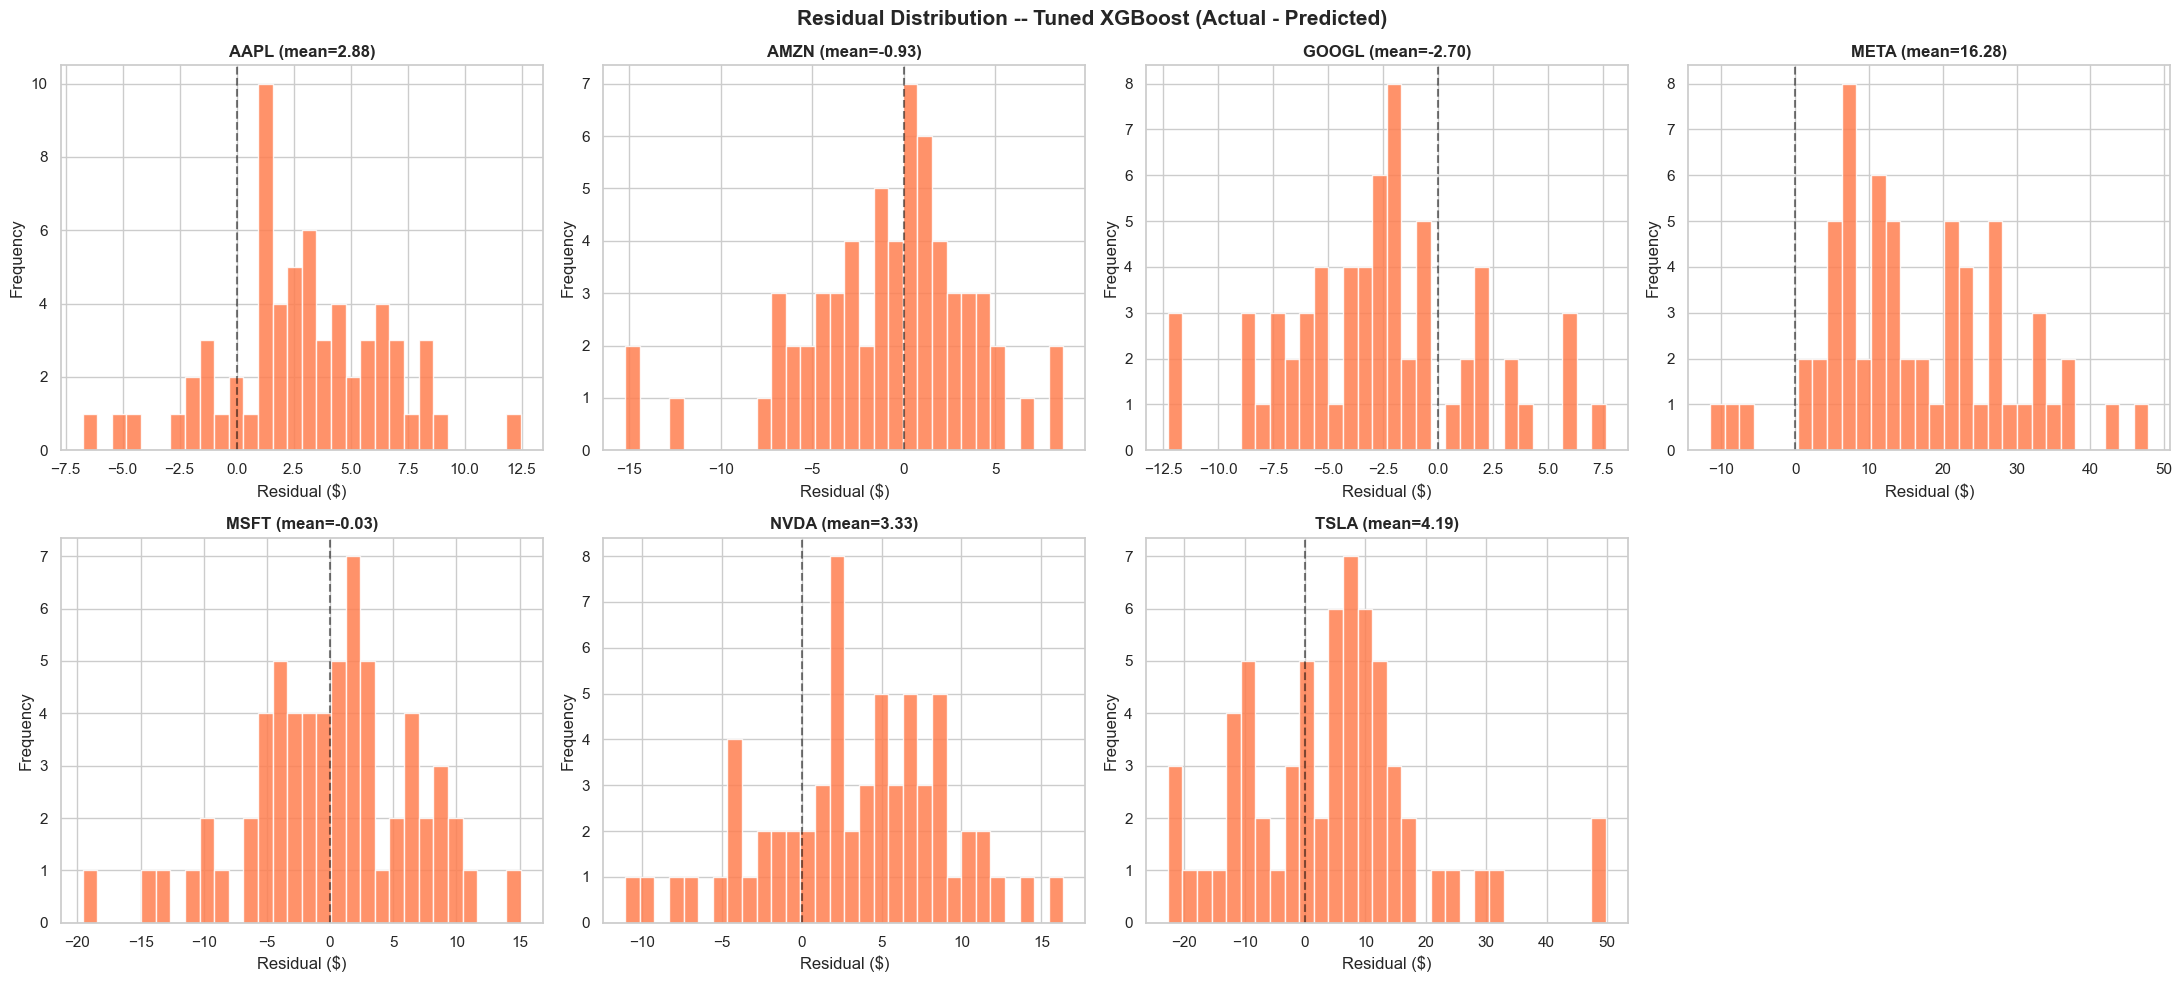

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    preds = tuned_all_predictions[ticker]
    residuals = preds['actual'] - preds['predicted']

    axes[i].hist(residuals, bins=30, edgecolor='white', alpha=0.85, color='coral')
    axes[i].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{ticker} (mean={residuals.mean():.2f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Residual ($)')
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
fig.suptitle('Residual Distribution -- Tuned XGBoost (Actual - Predicted)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Cumulative Error Over Time (Tuned Model)

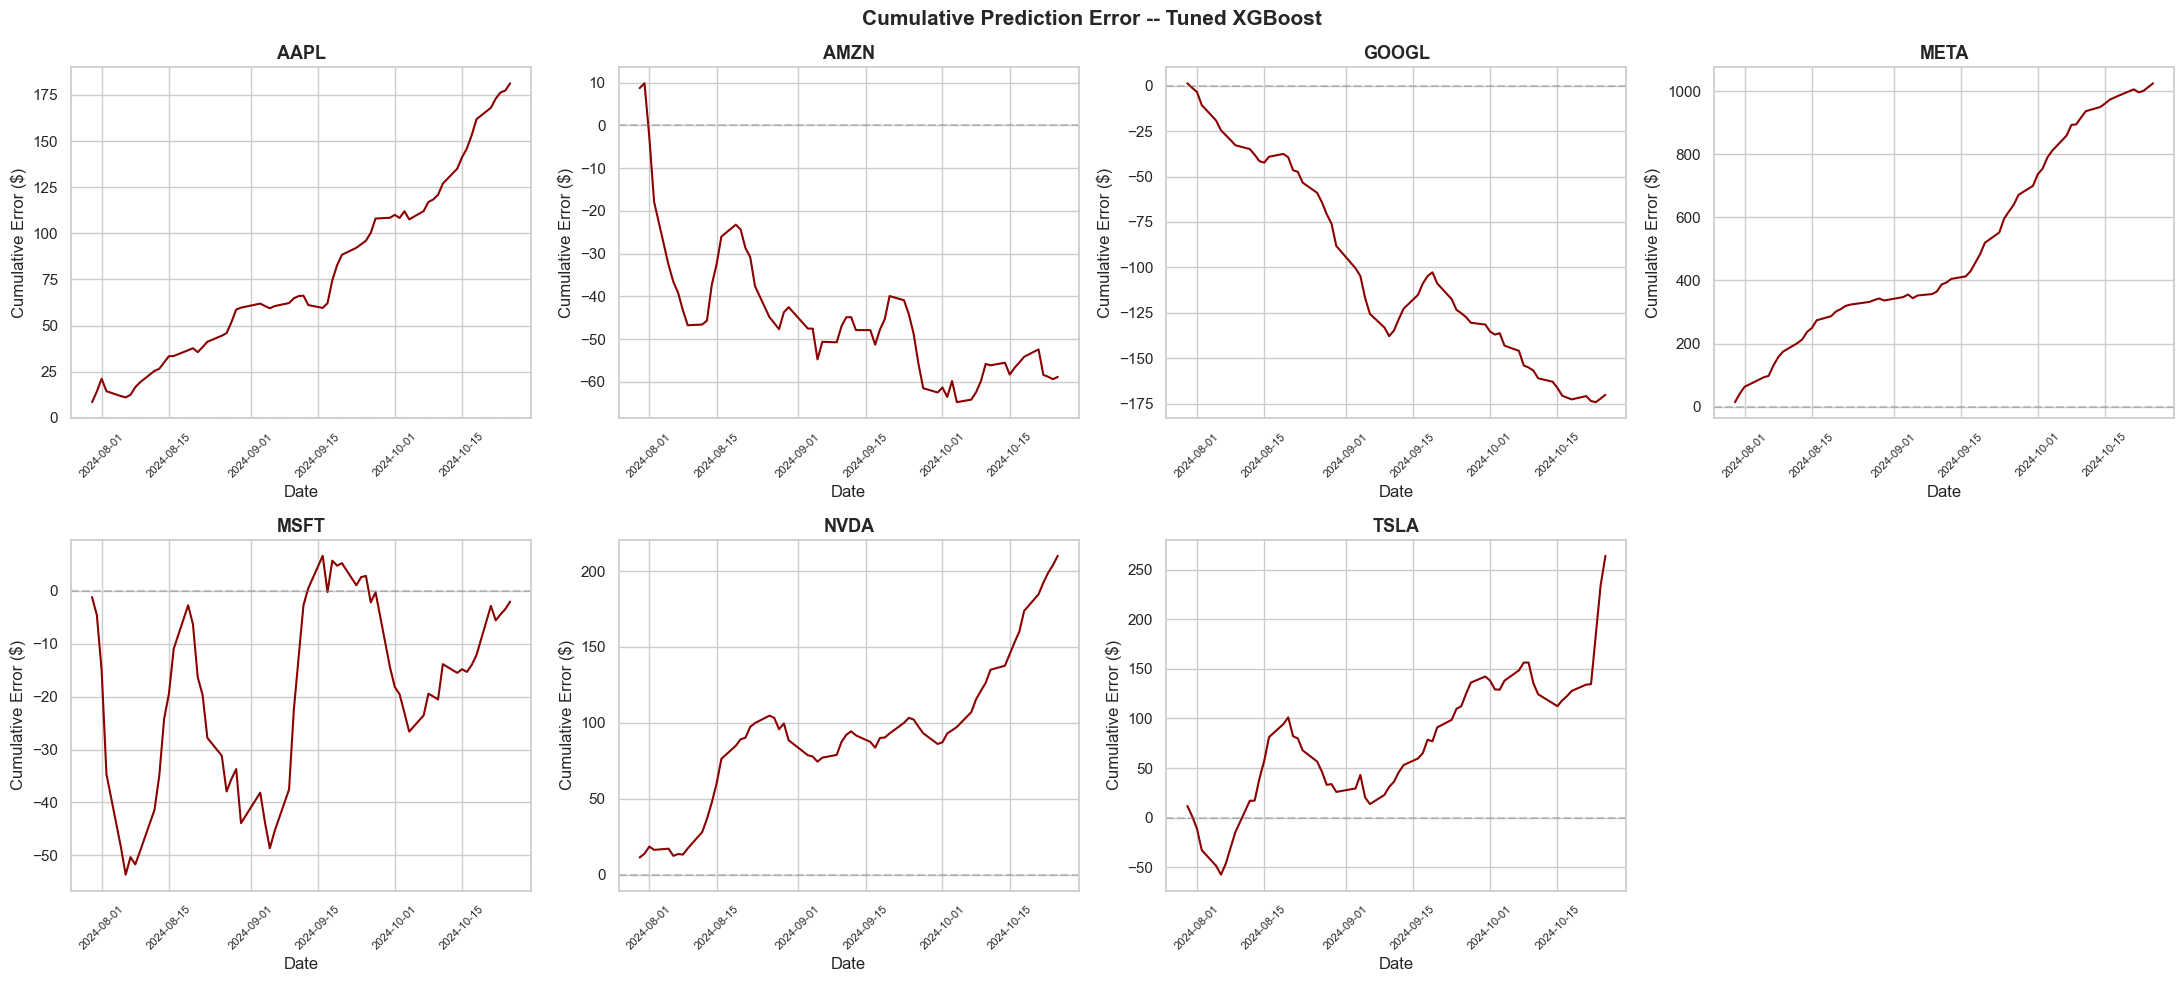

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    preds = tuned_all_predictions[ticker]
    residuals = preds['actual'] - preds['predicted']
    cum_error = residuals.cumsum()

    axes[i].plot(preds['date'], cum_error, linewidth=1.5, color='darkred')
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Cumulative Error ($)')

axes[-1].set_visible(False)
fig.suptitle('Cumulative Prediction Error -- Tuned XGBoost', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Feature Importance (Tuned Model)

Train one final XGBoost on the full training set per ticker and extract feature importances.

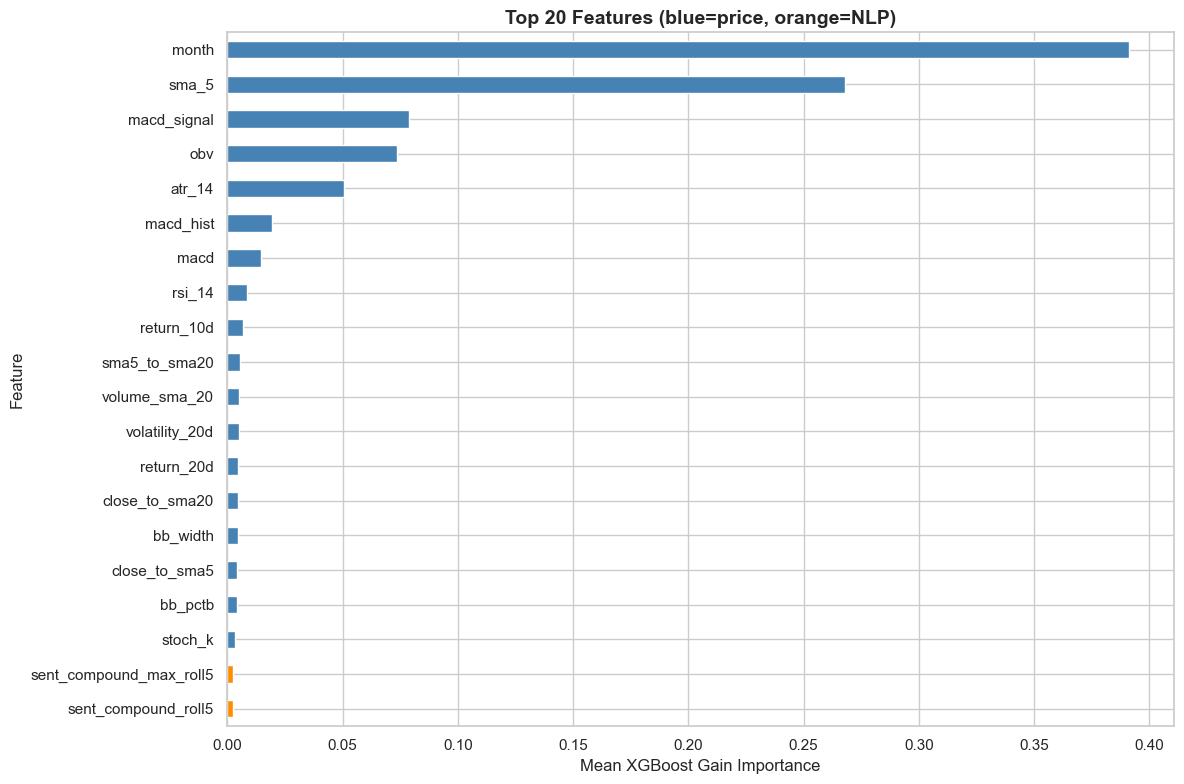


NLP Feature Importance Ranking:
  sent_compound_max_roll5             0.0024
  sent_compound_roll5                 0.0023
  sent_compound_std_roll5             0.0016
  positive_ratio_roll5                0.0015
  sent_positive                       0.0014
  sent_compound_min_roll5             0.0013
  emb_pca_6                           0.0012
  emb_pca_0                           0.0012
  positive_ratio                      0.0011
  negative_ratio_roll5                0.0011
  emb_pca_4                           0.0010
  sent_negative_roll5                 0.0009
  sent_compound                       0.0009
  emb_pca_12                          0.0009
  sent_compound_max                   0.0009
  emb_pca_2                           0.0008
  emb_pca_13                          0.0008
  sent_positive_roll5                 0.0008
  emb_pca_1                           0.0007
  emb_pca_10                          0.0007
  emb_pca_5                           0.0007
  negative_ratio      

In [16]:
final_importances = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    n = len(sub)
    split_idx = int(n * TRAIN_PCT)

    X_train = sub[all_feature_cols].values[:split_idx]
    y_train = sub['target_next_close'].values[:split_idx]

    model = make_tuned_xgb_model()
    model.fit(X_train, y_train)
    final_importances[ticker] = pd.Series(model.feature_importances_, index=all_feature_cols)

fi_df = pd.DataFrame(final_importances)
fi_df['mean'] = fi_df.mean(axis=1)
fi_df = fi_df.sort_values('mean', ascending=False)

top20 = fi_df.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['darkorange' if feat in nlp_feature_cols else 'steelblue' for feat in top20.index]
top20['mean'].sort_values().plot(
    kind='barh', ax=ax, color=colors[::-1], edgecolor='white'
)
ax.set_title('Top 20 Features (blue=price, orange=NLP)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean XGBoost Gain Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# NLP features ranking
nlp_fi = fi_df.loc[fi_df.index.isin(nlp_feature_cols), 'mean'].sort_values(ascending=False)
print('\nNLP Feature Importance Ranking:')
for feat, imp in nlp_fi.items():
    print(f'  {feat:<35} {imp:.4f}')

## 15. NLP Value Analysis -- Sentiment vs Price Movement

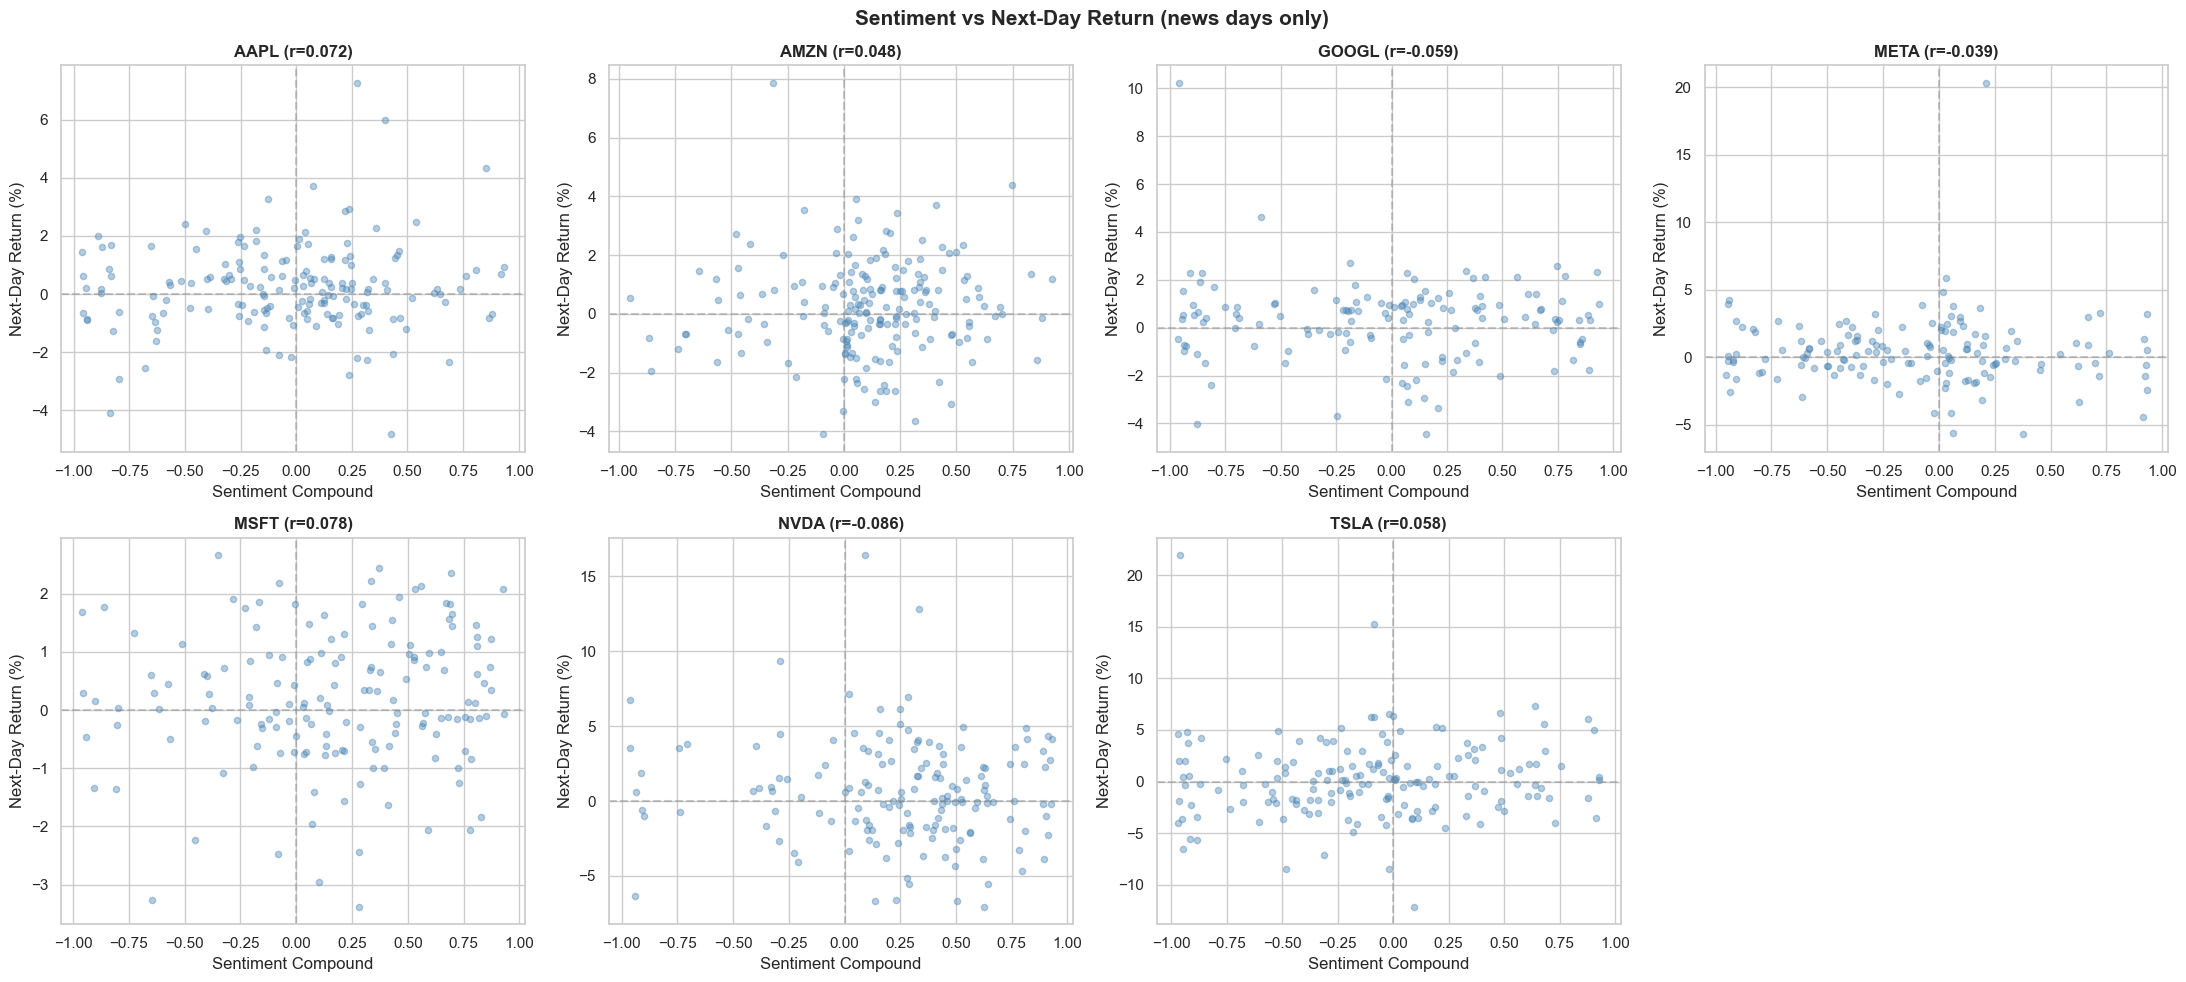

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    sub = df[df['ticker'] == ticker].copy()
    sub_news = sub[sub['has_news'] == 1]

    scatter = axes[i].scatter(
        sub_news['sent_compound'], sub_news['target_next_return'] * 100,
        alpha=0.4, s=20, c='steelblue'
    )
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[i].axvline(0, color='gray', linestyle='--', alpha=0.4)

    corr = sub_news[['sent_compound', 'target_next_return']].corr().iloc[0, 1]
    axes[i].set_title(f'{ticker} (r={corr:.3f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Sentiment Compound')
    axes[i].set_ylabel('Next-Day Return (%)')

axes[-1].set_visible(False)
fig.suptitle('Sentiment vs Next-Day Return (news days only)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusions

### Pipeline Summary

This notebook assembled a complete prediction pipeline:

1. **Feature matrix** -- merged 40 price-based technical features with 33 NLP/sentiment features per ticker per day
2. **Baselines** -- naive forecast (tomorrow = today's close) and SMA-5 forecast
3. **XGBoost walk-forward (default)** -- expanding window validation (`TRAIN_PCT` initial training, 5-day step, retrain each step)
4. **Hyperparameter optimization** -- GridSearchCV with TimeSeriesSplit (3 folds) over 6 key parameters
5. **XGBoost walk-forward (tuned)** -- re-run with optimized hyperparameters
6. **Ablation study** -- 6-model comparison (Naive, SMA-5, default/tuned × price-only/all features)

---

### Key Results (Average Across All 7 Tickers)

| Model | RMSE | MAE | MAPE (%) | Dir. Accuracy (%) |
|-------|------|-----|----------|-------------------|
| **Naive Baseline** | **5.15** | **3.80** | **1.62** | 47.4 |
| SMA-5 | 7.58 | 5.87 | 2.49 | 48.2 |
| XGBoost (Price Only) | 8.65 | 6.72 | 2.68 | 50.0 |
| XGBoost (Price + NLP) | 8.92 | 7.06 | 2.78 | **50.4** |

---

### Finding 1: More Modeling Complexity = Worse Error Metrics

The most striking result is that **each layer of added complexity degrades prediction accuracy on error metrics**:

- **Naive → SMA-5**: RMSE increases 47% (5.15 → 7.58). Smoothing destroys the strong autocorrelation signal.
- **SMA-5 → XGBoost (Price)**: RMSE increases 14% (7.58 → 8.65). 40 engineered features add noise rather than signal.
- **XGBoost (Price) → XGBoost (Price + NLP)**: RMSE increases 3% (8.65 → 8.92). 33 additional NLP features make it worse.

This is a textbook example of the **complexity-performance paradox** in financial time series: the more parameters and features a model has, the more opportunities it has to overfit to noise in a small dataset. The naive baseline -- which has zero parameters -- wins precisely because there is almost no learnable signal in next-day price changes.

### Finding 2: The Only Edge Is Directional -- And It's Razor-Thin

The sole dimension where XGBoost outperforms the naive baseline is **directional accuracy** (50.0--50.4% vs 47.4%). This is barely above a coin flip, but it suggests the model is capturing an extremely weak directional signal in the features. In practice, this 3-percentage-point edge would be erased by transaction costs.

### Finding 3: NLP Features Are Noise at This Scale

Adding 33 NLP/sentiment features to the 40 price features:
- **Worsened** RMSE (+3%), MAE (+5%), and MAPE (+4%)
- **Improved** directional accuracy by only 0.4 percentage points
- Feature importance analysis shows NLP features rank near the bottom, dominated by price-based technical indicators
- Rolling sentiment features (5-day means) outrank raw daily sentiment, but even these contribute negligibly

### Finding 4: Hyperparameter Tuning (GridSearchCV)

GridSearchCV with TimeSeriesSplit searched 729 combinations across `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, and `min_child_weight`. See the Default vs Tuned comparison in Section 9 for the impact. Given the fundamental constraint that the naive baseline dominates, tuning has limited room to improve results.

---

### Why These Results Are Expected

1. **Tiny dataset** (~207 trading days per ticker, ~145 initial training samples at `TRAIN_PCT`=0.7) -- far too small for XGBoost to learn robust nonlinear patterns; the model overfits to noise
2. **Walk-forward validation** is realistic but punishing -- the model encounters market regime changes (earnings, macro shifts) it was never trained on
3. **Next-day prediction is a near-random-walk problem** -- the Efficient Market Hypothesis predicts that short-term price changes are unpredictable; the autocorrelation of prices (today ≈ tomorrow) means a zero-parameter "model" (naive) is hard to beat
4. Many academic studies report the same finding when using proper time-series validation instead of random splits, which artificially inflate accuracy by leaking future information

### Implications

The results do **not** mean these models are useless -- they mean this particular problem setup (next-day close regression, 207-day window, walk-forward validation) is fundamentally constrained. The models would likely perform better with:

- **Longer prediction horizons** (5-day, 20-day returns) where autocorrelation weakens and trends become detectable
- **Classification framing** (up/down direction) instead of exact price regression, leveraging the directional edge
- **Substantially more data** -- 2--5 years of daily data per ticker would provide enough samples for XGBoost to distinguish signal from noise
- **Multi-ticker pooling** -- training one model across all 7 tickers with ticker as a feature, increasing effective sample size 7×